# ANALYSIS OF SCORES

In [1]:
import sys, pathlib
try:
    sys.path.insert(0, str(pathlib.Path.cwd().parent))
except ImportError as e:
    print(f"Error importing src: {e}")
from src.score import Score
from src.linear_predictor import LinearPredictor
import os
import src.constants as cn
import numpy as np  # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
from src.biomodels_iterator import BiomodelsIterator
from src.trajectory import Trajectory
from src.trajectory_collection import TrajectoryCollection
from src.multiple_linear_predictor import MultipleLinearPredictor

# Helpers

In [2]:
def evaluateMlp(model_num, num_splits=2, is_slow_subspace: bool = False,
                min_num_point_per_segment: int = 5, **kwargs):
    if not isinstance(num_splits, list):
        num_splits = [num_splits]
    trajectory = Trajectory.makeBiomodel(model_num=model_num, end_time=10)
    tcs = [TrajectoryCollection.autoSplit(trajectory, num_split=n,
            is_slow_subspace=is_slow_subspace, 
            min_num_point_per_segment=min_num_point_per_segment
            ) for n in num_splits]
    #
    lp = LinearPredictor(trajectory)
    lp.plotPrediction(**kwargs)
    #
    for tc in tcs:
        mlp = MultipleLinearPredictor(tc, is_slow_subspace=is_slow_subspace)
        mlp.plotPrediction(**kwargs)

# Timeseries Plots

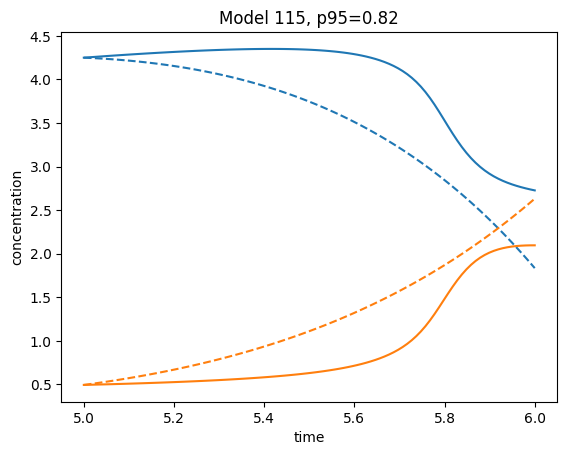

In [3]:
def plotModel(model_num, start_time=0, end_time=None, **kwargs):
    predictor = LinearPredictor.makeFromBiomodels(model_num=model_num, 
                start_time=start_time, end_time=end_time, num_step=-1, num_point=100,
                jacobian_selection=cn.JAC_FITTED)
    df = predictor.score()
    score_p95 = df.loc[0, 'p95']
    _ = predictor.plotPrediction(title=f"Model {model_num}, p95={score_p95:.2f}", **kwargs)


plotModel(115, start_time=5, end_time=6, legend=False)

Processing 1
Error fitting Jacobian: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information.
Falling back to JAC_MEDIAN.
Error fitting Jacobian: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information.
Falling back to JAC_MEDIAN.
Processing 2
Error fitting Jacobian: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information.
Falling back to JAC_MEDIAN.
Error fitting Jacobian: NaN values detected in your input data or the o

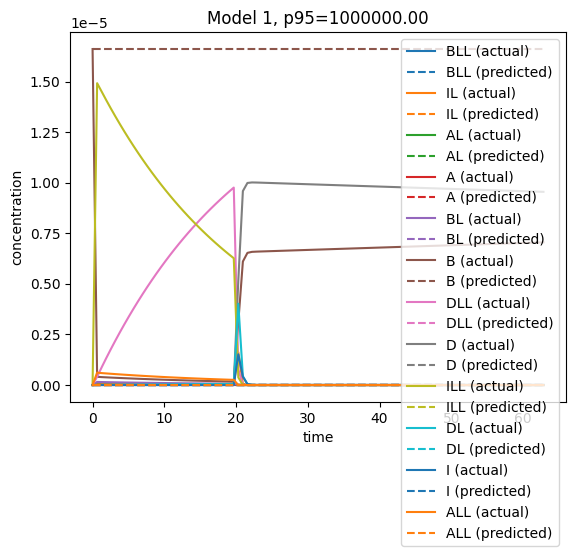

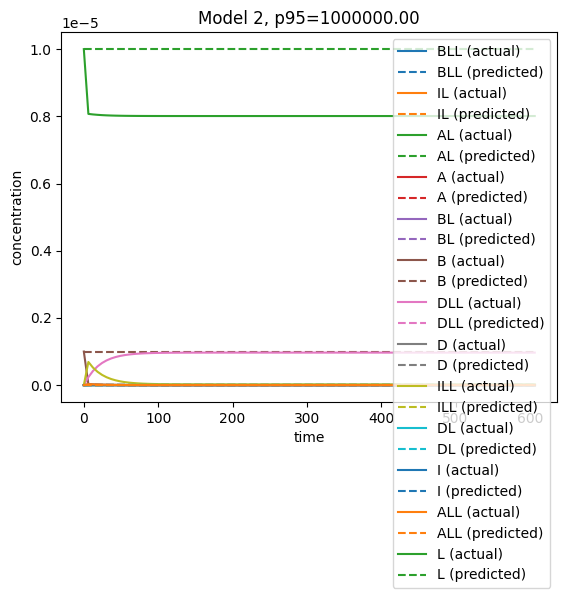

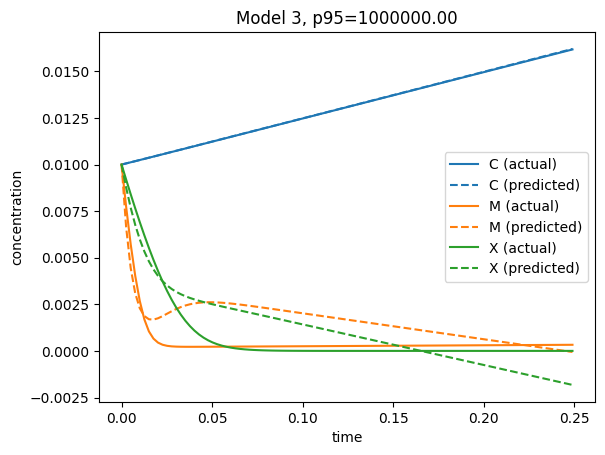

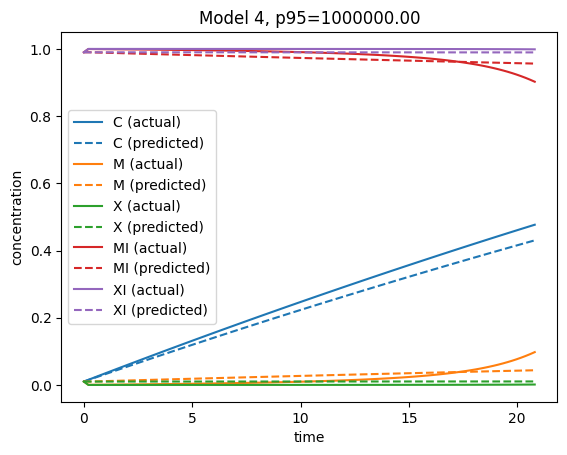

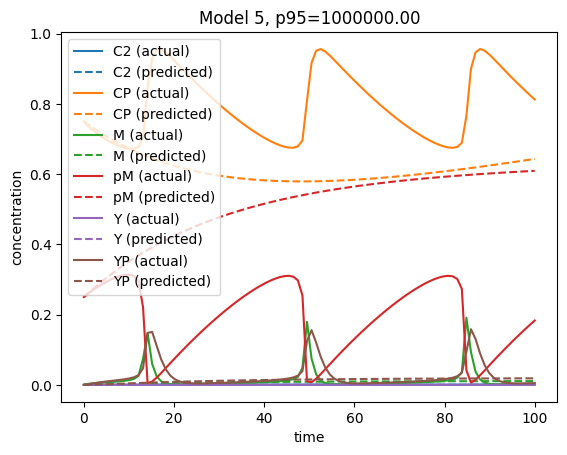

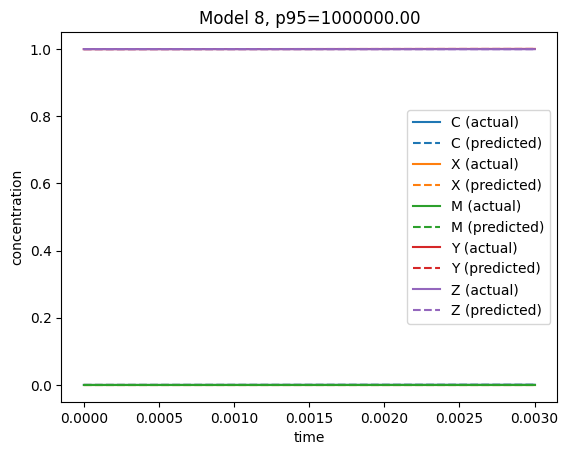

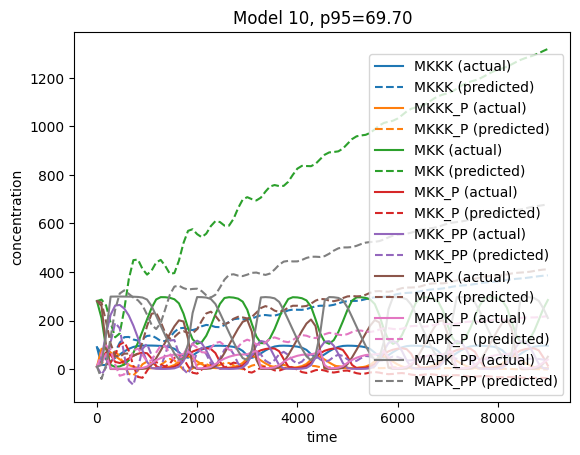

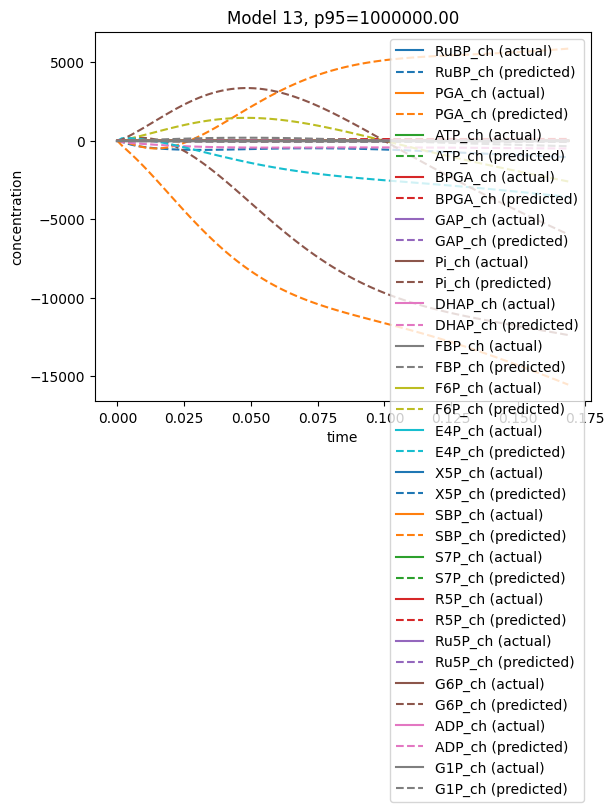

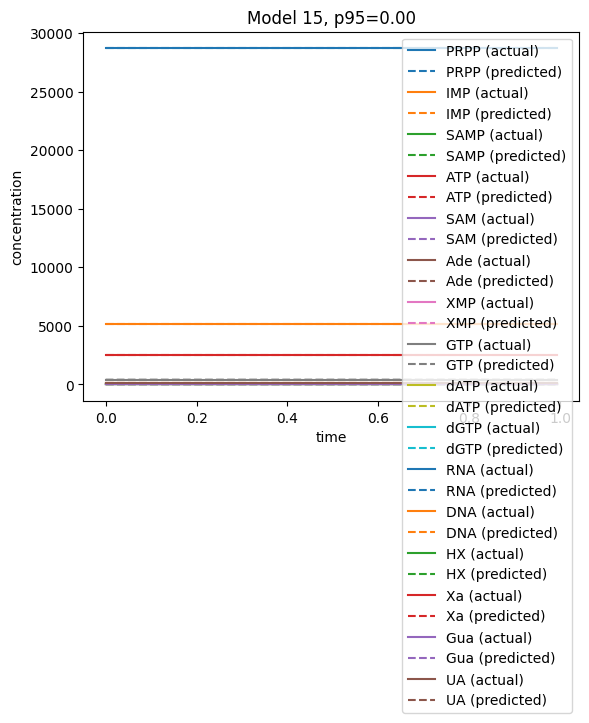

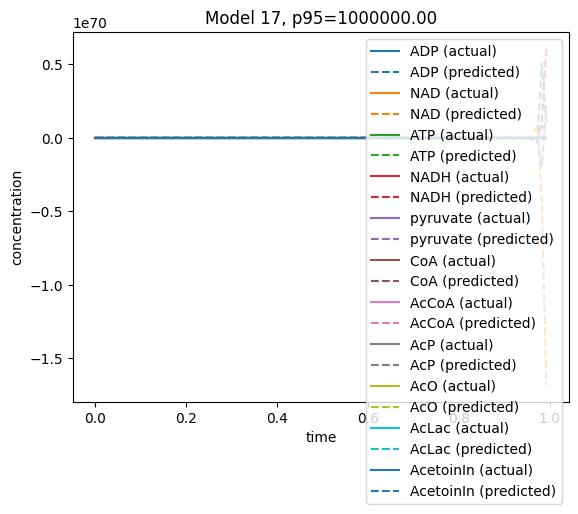

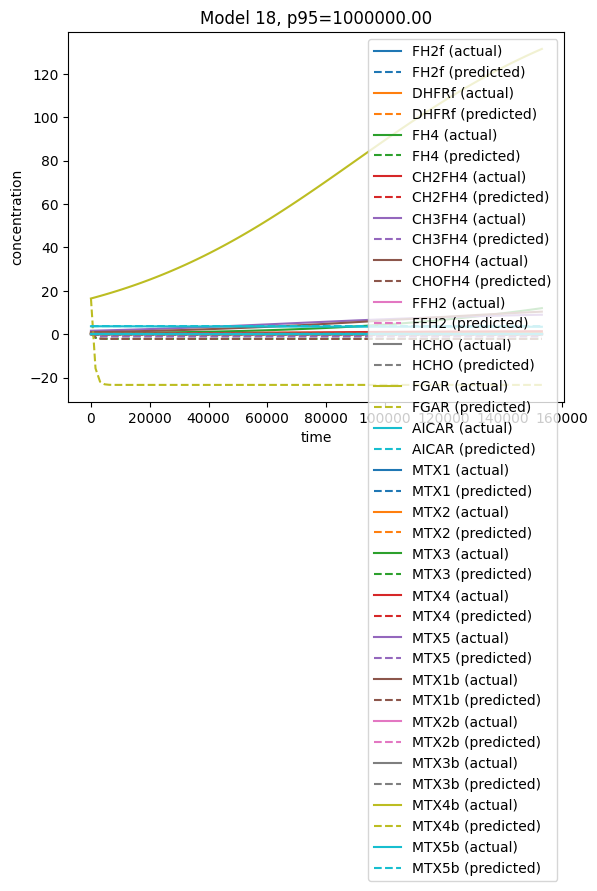

In [4]:
iterator = BiomodelsIterator(
            is_report=False,
            #excluded_models=excluded_models,
            first_model_num=1,
            last_model_num=20)
for item in iterator:
    if item.model_num in [11, 12, 14, 19, 48]:
        print(f"Excluding model {item.model_num}")
        continue
    try:
        print(f"Processing {item.model_num}")
        plotModel(item.model_num)
    except:
        print(f"Failed on model {item.model_num}")
    

# Splitting

Processing 1
Error fitting Jacobian: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information.
Falling back to JAC_MEDIAN.
Cannot use JAC_FITTED: num_species (12) > num_point (2).
Error occurred while processing segment 1: zero-size array to reduction operation fmin which has no identity


/Users/jlheller/home/Technical/repos/model_linearity_analysis/src/score.py:259: RuntimeWarning:

Mean of empty slice



Error fitting Jacobian: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information.
Falling back to JAC_MEDIAN.
Cannot use JAC_FITTED: num_species (12) > num_point (2).
Cannot use JAC_FITTED: num_species (12) > num_point (2).
Error occurred while processing segment 1: zero-size array to reduction operation fmin which has no identity
Error occurred while processing segment 2: zero-size array to reduction operation fmin which has no identity
Processing 2


/Users/jlheller/home/Technical/repos/model_linearity_analysis/src/score.py:259: RuntimeWarning:

Mean of empty slice



Error fitting Jacobian: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information.
Falling back to JAC_MEDIAN.
Error fitting Jacobian: Improper input: func input vector length N=13 must not exceed func output vector length M=12
Falling back to JAC_MEDIAN.
Error fitting Jacobian: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information.
Falling back to JAC_MEDIAN.
Cannot use JAC_FITTED: num_species (13) > num_point (2).
Cannot use JAC_FITTED: num_species (13) > num_point (12).
Error occurred while processing segment 1: zero-size array to reduction operation fmin which has no identity
Processing 3


...

/Users/jlheller/home/Technical/repos/model_linearity_analysis/src/score.py:259: RuntimeWarning:

Mean of empty slice



Cannot use JAC_FITTED: num_species (5) > num_point (2).
Error occurred while processing segment 1: zero-size array to reduction operation fmin which has no identity


/Users/jlheller/home/Technical/repos/model_linearity_analysis/src/score.py:259: RuntimeWarning:

Mean of empty slice



Cannot use JAC_FITTED: num_species (5) > num_point (2).
Cannot use JAC_FITTED: num_species (5) > num_point (2).
Error occurred while processing segment 1: zero-size array to reduction operation fmin which has no identity
Error occurred while processing segment 2: zero-size array to reduction operation fmin which has no identity


/Users/jlheller/home/Technical/repos/model_linearity_analysis/src/score.py:259: RuntimeWarning:

Mean of empty slice



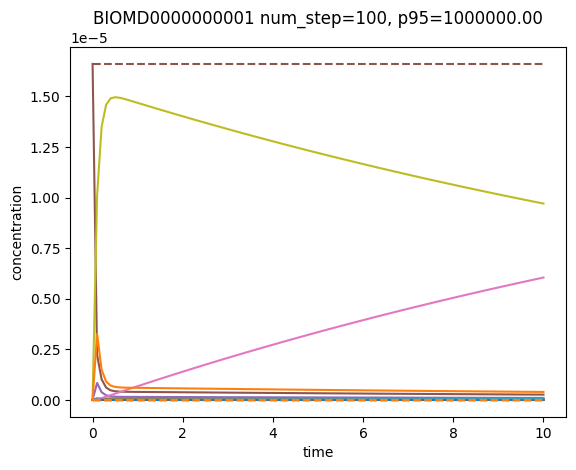

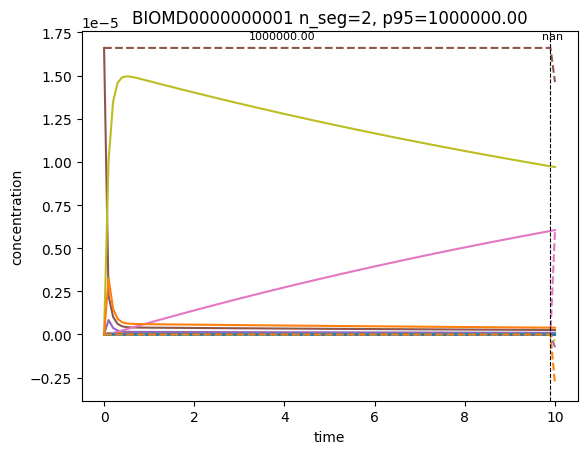

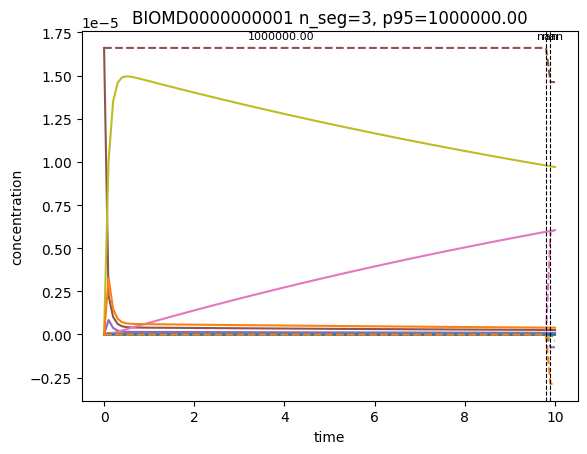

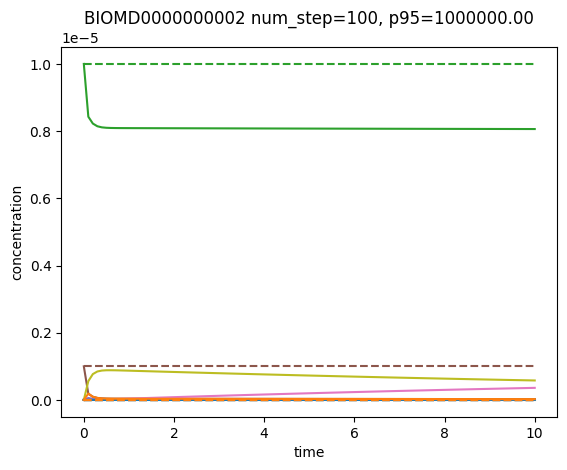

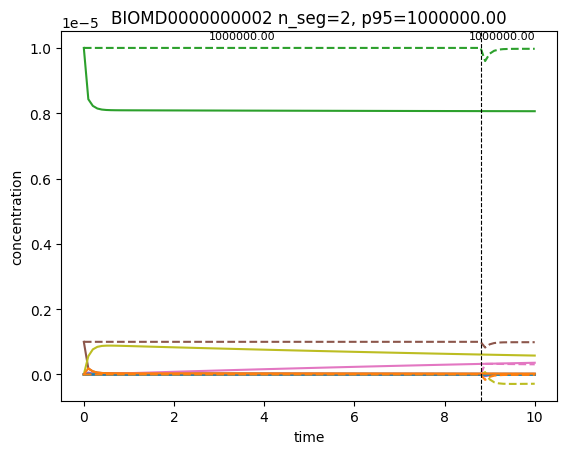

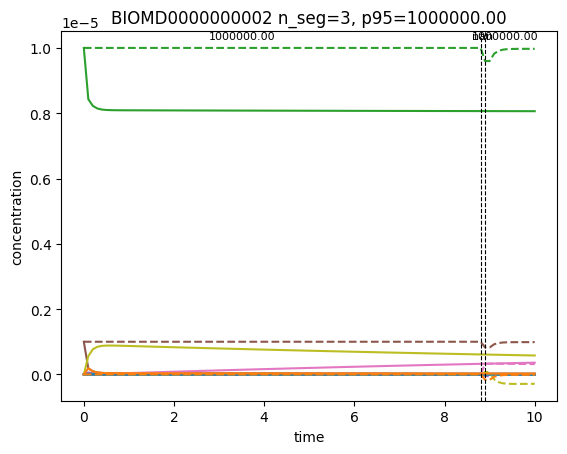

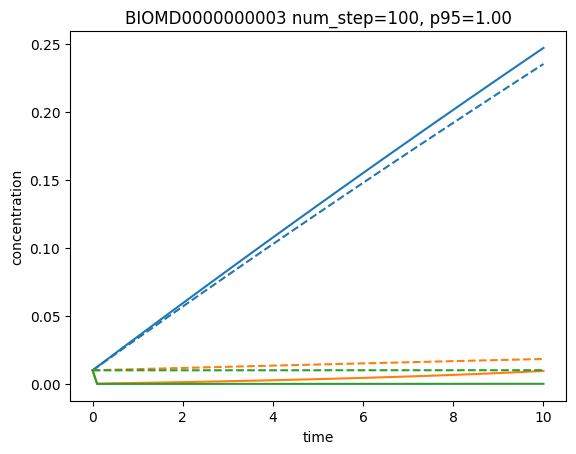

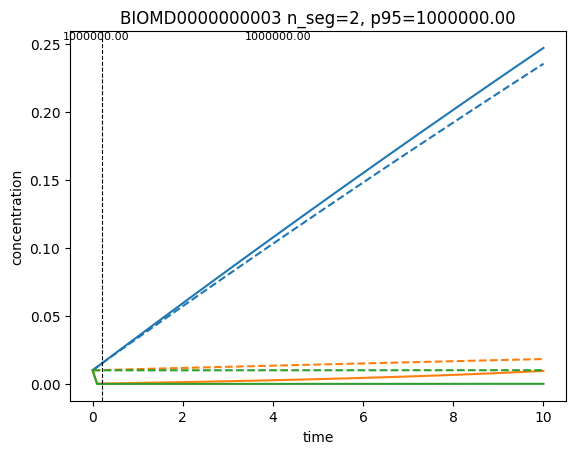

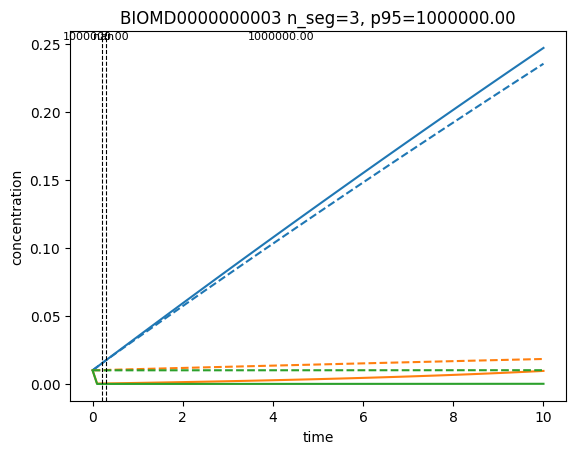

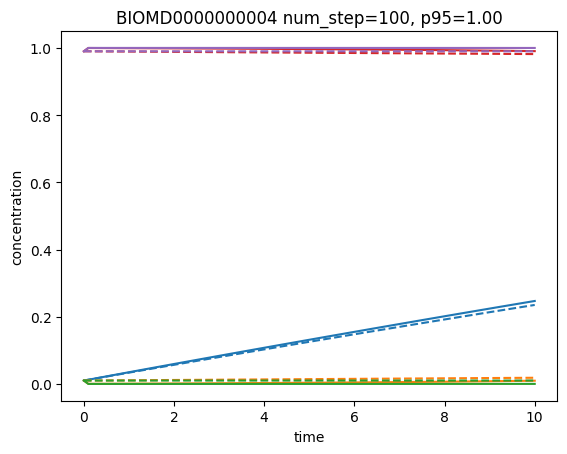

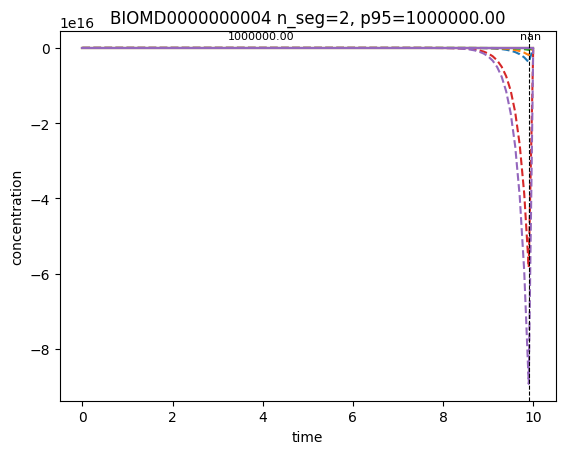

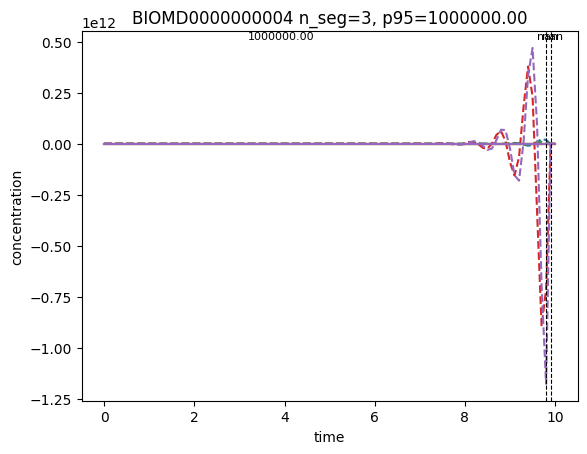

In [ ]:
iterator = BiomodelsIterator(
            is_report=False,
            #excluded_models=excluded_models,
            first_model_num=1,
            last_model_num=4)
for item in iterator:
    if item.model_num in [11, 13, 14, 19, 38, 41, 48, 50]:
        print(f"Excluding model {item.model_num}")
        continue
    try:
        print(f"Processing {item.model_num}")
        evaluateMlp(item.model_num, num_splits=[1, 2], legend=False,  # type: ignore
                    min_num_point_per_segment=5)
    except:
        print(f"Failed on model {item.model_num}")
    

# Histograms

## Aggregate Data

In [ ]:
ffiles = [f for f in os.listdir(cn.DATA_DIR) if "linear_predictor_score" in f]
dfs = []
for ffile in ffiles:
    df = pd.read_csv(os.path.join(cn.DATA_DIR, ffile))
    dfs.append(df)
merged_df = pd.concat(dfs)
ALL_DF = merged_df.reset_index()
ALL_PATH = "all_data.csv"
ALL_DF.to_csv(ALL_PATH)

In [ ]:
MODEL_DF = ALL_DF[ALL_DF["aggregation_type"] == "model"]
p95_arr = np.sort(MODEL_DF["p95"].values)
count = len(p95_arr)
_, ax = plt.subplots()
ax.plot(p95_arr, np.array(range(count))/count)
ax.set_xlim(0, 1)
ax.set_title(f"RAE 95th Percentile for {len(MODEL_DF)} Models")

In [ ]:
SPECIES_DF = ALL_DF[ALL_DF["aggregation_type"] != "model"]
p95_arr = np.sort(SPECIES_DF["p95"].values)
count = len(p95_arr)
_, ax = plt.subplots()
ax.plot(p95_arr, np.array(range(count))/count)
ax.set_xlim(0, 1)
ax.set_title(f"RAE 95th Percentile for {len(SPECIES_DF)} Species")